# Personalized Recommendation System with Multiple Embedding Types

This notebook compares multiple text representations for content-based coffee recommendation using the same preprocessing family as the origin-classification notebooks.

Offline evaluation uses a proxy relevance definition:
- query item: a coffee review from the validation or test split
- candidate pool: coffees from the training split
- relevant items: coffees in the candidate pool with the same `Country` label as the query

This is a ranking proxy, not a direct substitute for a user study.


In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from gensim.models import Word2Vec, FastText
import gensim.downloader as api

from nltk.stem import PorterStemmer, WordNetLemmatizer

from sentence_transformers import SentenceTransformer
from transformers import AutoModel, AutoTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split


In [2]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 30
TOP_K = 10
VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pd.set_option('display.max_colwidth', 120)
df = pd.read_csv(DATA_PATH)
df.head(2)


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Flavor,Aftertaste,With Milk,Blind Assessment,Notes,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country
0,https://www.coffeereview.com/review/100-arabica-coffee-puerto-rico/,"87\nCaribeans\n100% Arabica Coffee from Puerto Rico\nRoaster Location:\nSan Juan, Puerto Rico\nCoffee Origin:\nUtuad...",87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,8.0,7.0,NaN,"bittersweet but balanced; chocolaty. dark chocolate, dried fig, raisin, pistachio, fir in aroma and cup. brisk, dry ...",Produced on a single farm in the central mountains of Puerto Rico near the site of the Ceremonial Ball Courts built ...,NaN,Satisfying chocolate and nut notes nearly carry the day in this briskly bittersweet coffee from Puerto Rico.,7.0,Puerto Rico; China,Puerto Rico
1,https://www.coffeereview.com/review/100-arabica-freeze-dried-colombian-instant-coffee/,"88\nWaka Coffee\n100% Arabica Freeze-Dried Colombian (Instant Coffee)\nRoaster Location:\nLos Angeles, California\nC...",88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant Coffee),"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,8.0,8.0,NaN,evaluated at proportions of 5 grams of instant coffee powder mixed with 8.5 ounces (250 ml) of hot water. caramel-to...,The green coffee for this product was produced in Colombia from trees of the Arabica species. It was solubilized by ...,NaN,A appealing 100% Colombia coffee in instant format that largely preserves the character of the green coffee.,7.0,Colombia,Colombia


In [3]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

coffee_terms_to_keep = {
    'acid', 'acidity', 'aromatic', 'berry', 'bright', 'buttery', 'caramel', 'cherry',
    'chocolate', 'citrus', 'clean', 'cocoa', 'creamy', 'crisp', 'dark', 'drying',
    'earthy', 'finish', 'flavor', 'floral', 'flower', 'fruit', 'fruity', 'honey',
    'jasmine', 'juicy', 'lemon', 'lime', 'mouthfeel', 'nectarine', 'nut', 'nutty',
    'orange', 'peach', 'rose', 'round', 'silky', 'smooth', 'spice', 'spicy', 'stone',
    'sweet', 'syrupy', 'tangerine', 'tea', 'tone', 'vanilla', 'winey'
}
stop_words = set(ENGLISH_STOP_WORDS) - coffee_terms_to_keep

misspelling_replacements = {
    r'\bchocolaty\b': 'chocolate',
    r'\bchoclate\b': 'chocolate',
    r'\bcitrussy\b': 'citrus',
    r'\bcitricy\b': 'citrus',
    r'\bcaramelly\b': 'caramel',
    r'\bcarmel\b': 'caramel',
    r'\bflorals\b': 'floral',
    r'\bfruity\b': 'fruit',
    r'\bnutty\b': 'nut',
    r'\bberries\b': 'berry',
}

phrase_replacements = {
    r'\bdark\s+chocolate\b': 'dark_chocolate',
    r'\bmilk\s+chocolate\b': 'milk_chocolate',
    r'\bbaking\s+chocolate\b': 'baking_chocolate',
    r'\bstone\s+fruit\b': 'stone_fruit',
    r'\borange\s+zest\b': 'orange_zest',
    r'\blemon\s+zest\b': 'lemon_zest',
    r'\bbrown\s+sugar\b': 'brown_sugar',
    r'\bred\s+apple\b': 'red_apple',
    r'\bpipe\s+tobacco\b': 'pipe_tobacco',
    r'\baromatic\s+wood\b': 'aromatic_wood',
    r'\btea\s+rose\b': 'tea_rose',
    r'\bdried\s+berry\b': 'dried_berry',
    r'\bchocolatey\b': 'chocolate',
    r'\bcocoa\s+toned\b': 'cocoa',
    r'\bcitrusy\b': 'citrus',
    r'\bberry\s+like\b': 'berry',
    r'\bberrylike\b': 'berry',
    r'\bfruit\s+toned\b': 'fruit',
    r'\bfloral\s+toned\b': 'floral',
    r'\bnut\s+toned\b': 'nut',
    r'\bcaramel\s+like\b': 'caramel',
    r'\bsweet\s+toned\b': 'sweet',
}


def minimal_raw_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def apply_replacements(text: str) -> str:
    for pattern, replacement in misspelling_replacements.items():
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in phrase_replacements.items():
        text = re.sub(pattern, replacement, text)
    return text


def normalize_text(text: str) -> str:
    text = minimal_raw_text(text).lower()
    text = apply_replacements(text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def remove_domain_stopwords(text: str) -> str:
    tokens = [token for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_stem(text: str) -> str:
    tokens = [stemmer.stem(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_lemmatize(text: str) -> str:
    tokens = [lemmatizer.lemmatize(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def tokenize_text(text: str):
    return [token for token in text.split() if len(token.strip()) > 1]



In [4]:
# Build text variants
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)
df['text_domain_stopwords'] = df['text_basic'].map(remove_domain_stopwords)
df['text_domain_stopwords_stemmed'] = df['text_basic'].map(remove_domain_stopwords_and_stem)
df['text_domain_stopwords_lemmatized'] = df['text_basic'].map(remove_domain_stopwords_and_lemmatize)

# Keep a country label for offline ranking evaluation
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()
work = work.reset_index(drop=True)

summary_df = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after filtering',
        'Unique origin classes',
        'Min samples per class',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
    ]
})
summary_df


,metric,value
0,Rows in raw dataset,7585
1,Rows after filtering,7437
2,Unique origin classes,25
3,Min samples per class,30


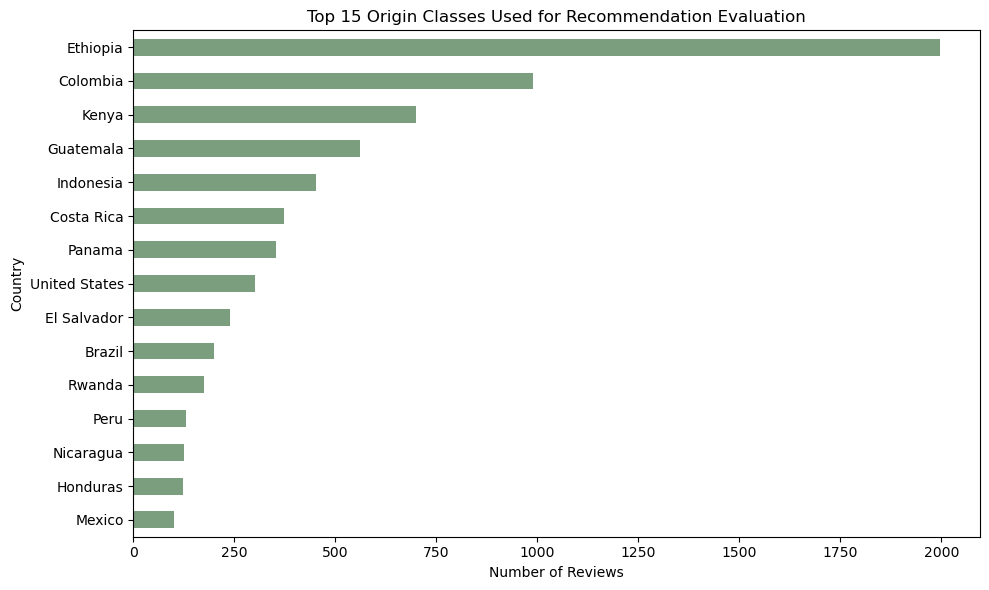

In [5]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()
plt.figure(figsize=(10, 6))
origin_counts.plot(kind='barh', color='#7A9E7E')
plt.title('Top 15 Origin Classes Used for Recommendation Evaluation')
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


In [6]:
# Split queries from candidate pool using the same 70/15/15 stratified pattern
y = work['origin_country']
row_idx = work.index

train_idx, temp_idx = train_test_split(
    row_idx,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y.loc[temp_idx],
)

train_pool = work.loc[train_idx].reset_index(drop=True)
val_queries = work.loc[val_idx].reset_index(drop=True)
test_queries = work.loc[test_idx].reset_index(drop=True)

print('Train pool size:', len(train_pool))
print('Validation query size:', len(val_queries))
print('Test query size:', len(test_queries))


Train pool size: 5205
Validation query size: 1116
Test query size: 1116


In [7]:
def precision_at_k(relevance, k):
    relevance = np.asarray(relevance[:k], dtype=np.float32)
    if k == 0:
        return 0.0
    return float(relevance.sum() / k)


def recall_at_k(relevance, total_relevant, k):
    if total_relevant == 0:
        return np.nan
    relevance = np.asarray(relevance[:k], dtype=np.float32)
    return float(relevance.sum() / total_relevant)


def dcg_at_k(relevance, k):
    relevance = np.asarray(relevance[:k], dtype=np.float32)
    if relevance.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, relevance.size + 2))
    return float(np.sum(relevance / discounts))


def ndcg_at_k(relevance, total_relevant, k):
    ideal_relevance = np.ones(min(total_relevant, k), dtype=np.float32)
    ideal = dcg_at_k(ideal_relevance, k)
    if ideal == 0:
        return np.nan
    return dcg_at_k(relevance, k) / ideal


def average_precision_at_k(relevance, total_relevant, k):
    if total_relevant == 0:
        return np.nan
    relevance = np.asarray(relevance[:k], dtype=np.int32)
    precisions = []
    hits = 0
    for i, rel in enumerate(relevance, start=1):
        if rel:
            hits += 1
            precisions.append(hits / i)
    if not precisions:
        return 0.0
    return float(np.sum(precisions) / min(total_relevant, k))


def compute_ranking_metrics(similarity_matrix, query_labels, candidate_labels, k=TOP_K):
    query_labels = pd.Series(query_labels).reset_index(drop=True)
    candidate_labels = pd.Series(candidate_labels).reset_index(drop=True)

    metrics = []
    for i in range(similarity_matrix.shape[0]):
        sims = similarity_matrix[i]
        order = np.argsort(-sims)
        ranked_labels = candidate_labels.iloc[order].tolist()
        query_label = query_labels.iloc[i]
        relevance = [1 if label == query_label else 0 for label in ranked_labels[:k]]
        total_relevant = int((candidate_labels == query_label).sum())
        metrics.append({
            'precision_at_k': precision_at_k(relevance, k),
            'recall_at_k': recall_at_k(relevance, total_relevant, k),
            'ndcg_at_k': ndcg_at_k(relevance, total_relevant, k),
            'map_at_k': average_precision_at_k(relevance, total_relevant, k),
        })

    metrics_df = pd.DataFrame(metrics)
    return {
        'precision_at_k': metrics_df['precision_at_k'].mean(),
        'recall_at_k': metrics_df['recall_at_k'].dropna().mean(),
        'ndcg_at_k': metrics_df['ndcg_at_k'].dropna().mean(),
        'map_at_k': metrics_df['map_at_k'].dropna().mean(),
    }


In [8]:
glove_kv = None
try:
    glove_kv = api.load('glove-wiki-gigaword-100')
    print('Loaded GloVe: glove-wiki-gigaword-100')
except Exception as e:
    print('Could not load GloVe. GloVe experiments will be skipped.')
    print('Reason:', e)

bert_tokenizer = None
bert_model = None
sbert_model = None


def load_bert_model(model_name='bert-base-uncased'):
    global bert_tokenizer, bert_model
    if bert_tokenizer is None or bert_model is None:
        bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
        bert_model = AutoModel.from_pretrained(model_name).to(DEVICE)
        bert_model.eval()
    return bert_tokenizer, bert_model


def load_sbert_model(model_name='all-MiniLM-L6-v2'):
    global sbert_model
    if sbert_model is None:
        sbert_model = SentenceTransformer(model_name, device=DEVICE)
    return sbert_model


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def encode_texts_bert(texts, model_name='bert-base-uncased', batch_size=BATCH_SIZE):
    tokenizer, model = load_bert_model(model_name)
    all_embeddings = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt').to(DEVICE)
            outputs = model(**encoded)
            pooled = mean_pooling(outputs.last_hidden_state, encoded['attention_mask'])
            all_embeddings.append(pooled.cpu().numpy())
    return np.vstack(all_embeddings)


def encode_texts_sbert(texts, model_name='all-MiniLM-L6-v2', batch_size=BATCH_SIZE):
    model = load_sbert_model(model_name)
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=False)


def build_idf_map(train_texts):
    vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), min_df=2, max_df=0.95)
    vec.fit(train_texts)
    return dict(zip(vec.get_feature_names_out(), vec.idf_))


def lookup_vector(token, kv):
    candidates = [token, token.lower(), token.strip(string.punctuation), token.lower().strip(string.punctuation)]
    for candidate in candidates:
        if candidate and candidate in kv.key_to_index:
            return kv[candidate]
    return None


def docs_to_weighted_vectors(token_docs, kv, idf_map, vector_size=100):
    X = np.zeros((len(token_docs), vector_size), dtype=np.float32)
    for i, tokens in enumerate(token_docs):
        weighted_vecs = []
        weights = []
        for token in tokens:
            vec = lookup_vector(token, kv)
            if vec is not None:
                clean_token = token.lower().strip(string.punctuation)
                weight = idf_map.get(clean_token, idf_map.get(token, 1.0))
                weighted_vecs.append(vec * weight)
                weights.append(weight)
        if weights:
            X[i] = np.sum(weighted_vecs, axis=0) / np.sum(weights)
    return X


def build_embedding_kv(embedding_name, train_token_docs):
    if embedding_name == 'Word2Vec':
        model = Word2Vec(
            sentences=train_token_docs,
            vector_size=VECTOR_SIZE,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=1,
            seed=RANDOM_STATE,
        )
        return model.wv
    if embedding_name == 'fastText':
        model = FastText(
            sentences=train_token_docs,
            vector_size=VECTOR_SIZE,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=1,
            seed=RANDOM_STATE,
        )
        return model.wv
    if embedding_name == 'GloVe':
        return glove_kv
    raise ValueError(f'Unknown embedding: {embedding_name}')


def encode_static_split(embedding_name, train_texts, query_texts):
    train_tokens = [tokenize_text(text) for text in train_texts]
    query_tokens = [tokenize_text(text) for text in query_texts]
    kv = build_embedding_kv(embedding_name, train_tokens)
    if kv is None:
        return None, None
    idf_map = build_idf_map(train_texts)
    train_vecs = docs_to_weighted_vectors(train_tokens, kv, idf_map, VECTOR_SIZE)
    query_vecs = docs_to_weighted_vectors(query_tokens, kv, idf_map, VECTOR_SIZE)
    return train_vecs, query_vecs


def encode_tfidf_split(train_texts, query_texts):
    vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=3, max_df=0.90, sublinear_tf=True)
    train_vecs = vectorizer.fit_transform(train_texts)
    query_vecs = vectorizer.transform(query_texts)
    return train_vecs, query_vecs


def encode_embeddings(embedding_name, train_texts, query_texts):
    if embedding_name == 'TF-IDF':
        return encode_tfidf_split(train_texts, query_texts)
    if embedding_name in {'Word2Vec', 'fastText', 'GloVe'}:
        return encode_static_split(embedding_name, train_texts, query_texts)
    if embedding_name == 'BERT':
        return encode_texts_bert(train_texts), encode_texts_bert(query_texts)
    if embedding_name == 'Sentence-BERT':
        return encode_texts_sbert(train_texts), encode_texts_sbert(query_texts)
    raise ValueError(f'Unknown embedding: {embedding_name}')


def evaluate_retrieval(embedding_name, train_texts, query_texts, query_labels, train_labels, k=TOP_K):
    train_vecs, query_vecs = encode_embeddings(embedding_name, train_texts, query_texts)
    if train_vecs is None or query_vecs is None:
        return None
    similarity = cosine_similarity(query_vecs, train_vecs)
    return compute_ranking_metrics(similarity, query_labels, train_labels, k=k)


Loaded GloVe: glove-wiki-gigaword-100


In [9]:
preprocessing_variants = {
    'Raw text / punctuation preserved': 'text_raw_minimal',
    'Basic normalization': 'text_basic',
    'Domain stopword removal': 'text_domain_stopwords',
    'Domain stopword removal + stemming': 'text_domain_stopwords_stemmed',
    'Domain stopword removal + lemmatization': 'text_domain_stopwords_lemmatized',
}

ablation_results = []
best_preprocessing_name = None
best_text_column = None
best_preprocessing_val_ndcg = -1

for variant_name, column_name in preprocessing_variants.items():
    train_texts = train_pool[column_name].tolist()
    val_texts = val_queries[column_name].tolist()
    test_texts = test_queries[column_name].tolist()

    val_metrics = evaluate_retrieval('TF-IDF', train_texts, val_texts, val_queries['origin_country'], train_pool['origin_country'])
    test_metrics = evaluate_retrieval('TF-IDF', train_texts, test_texts, test_queries['origin_country'], train_pool['origin_country'])

    row = {
        'preprocessing_variant': variant_name,
        'text_column': column_name,
        'val_precision_at_k': val_metrics['precision_at_k'],
        'val_recall_at_k': val_metrics['recall_at_k'],
        'val_ndcg_at_k': val_metrics['ndcg_at_k'],
        'val_map_at_k': val_metrics['map_at_k'],
        'test_precision_at_k': test_metrics['precision_at_k'],
        'test_recall_at_k': test_metrics['recall_at_k'],
        'test_ndcg_at_k': test_metrics['ndcg_at_k'],
        'test_map_at_k': test_metrics['map_at_k'],
    }
    ablation_results.append(row)

    if val_metrics['ndcg_at_k'] > best_preprocessing_val_ndcg:
        best_preprocessing_val_ndcg = val_metrics['ndcg_at_k']
        best_preprocessing_name = variant_name
        best_text_column = column_name

ablation_results_df = pd.DataFrame(ablation_results).sort_values('val_ndcg_at_k', ascending=False).reset_index(drop=True)
print('Selected preprocessing variant:', best_preprocessing_name)
print('Selected text column:', best_text_column)
ablation_results_df


Selected preprocessing variant: Domain stopword removal + stemming
Selected text column: text_domain_stopwords_stemmed


,preprocessing_variant,text_column,val_precision_at_k,val_recall_at_k,val_ndcg_at_k,val_map_at_k,test_precision_at_k,test_recall_at_k,test_ndcg_at_k,test_map_at_k
0,Domain stopword removal + stemming,text_domain_stopwords_stemmed,0.198925,0.004016,0.207785,0.114596,0.191308,0.004144,0.201096,0.110653
1,Domain stopword removal + lemmatization,text_domain_stopwords_lemmatized,0.195968,0.003911,0.205592,0.113409,0.191129,0.004126,0.201352,0.109919
2,Domain stopword removal,text_domain_stopwords,0.196774,0.003898,0.205558,0.113667,0.191129,0.004096,0.200623,0.109301
3,Basic normalization,text_basic,0.190323,0.003724,0.200431,0.108679,0.190591,0.004131,0.197960,0.107469
4,Raw text / punctuation preserved,text_raw_minimal,0.189785,0.003820,0.200066,0.108058,0.191219,0.004149,0.199697,0.109152


In [10]:
embedding_names = ['TF-IDF', 'Word2Vec', 'fastText', 'BERT', 'Sentence-BERT']
if glove_kv is not None:
    embedding_names.insert(3, 'GloVe')

train_texts = train_pool[best_text_column].tolist()
val_texts = val_queries[best_text_column].tolist()
test_texts = test_queries[best_text_column].tolist()

search_results = []
best_embedding_name = None
best_val_ndcg = -1

for embedding_name in embedding_names:
    val_metrics = evaluate_retrieval(embedding_name, train_texts, val_texts, val_queries['origin_country'], train_pool['origin_country'])
    if val_metrics is None:
        continue
    test_metrics = evaluate_retrieval(embedding_name, train_texts, test_texts, test_queries['origin_country'], train_pool['origin_country'])

    row = {
        'embedding_name': embedding_name,
        'val_precision_at_k': val_metrics['precision_at_k'],
        'val_recall_at_k': val_metrics['recall_at_k'],
        'val_ndcg_at_k': val_metrics['ndcg_at_k'],
        'val_map_at_k': val_metrics['map_at_k'],
        'test_precision_at_k': test_metrics['precision_at_k'],
        'test_recall_at_k': test_metrics['recall_at_k'],
        'test_ndcg_at_k': test_metrics['ndcg_at_k'],
        'test_map_at_k': test_metrics['map_at_k'],
    }
    search_results.append(row)

    if val_metrics['ndcg_at_k'] > best_val_ndcg:
        best_val_ndcg = val_metrics['ndcg_at_k']
        best_embedding_name = embedding_name

search_results_df = pd.DataFrame(search_results).sort_values('val_ndcg_at_k', ascending=False).reset_index(drop=True)
print('Selected embedding:', best_embedding_name)
search_results_df


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Selected embedding: TF-IDF


,embedding_name,val_precision_at_k,val_recall_at_k,val_ndcg_at_k,val_map_at_k,test_precision_at_k,test_recall_at_k,test_ndcg_at_k,test_map_at_k
0,TF-IDF,0.198925,0.004016,0.207785,0.114596,0.191308,0.004144,0.201096,0.110653
1,Word2Vec,0.186111,0.003458,0.190264,0.102918,0.180914,0.003672,0.184791,0.099227
2,fastText,0.186290,0.003531,0.189898,0.102650,0.180018,0.003600,0.183271,0.096236
3,Sentence-BERT,0.181452,0.003432,0.188013,0.100061,0.183961,0.003415,0.190363,0.101907
4,GloVe,0.174373,0.002988,0.180595,0.096878,0.166487,0.003146,0.170755,0.089226
5,BERT,0.169444,0.002767,0.175313,0.092308,0.169892,0.002926,0.175379,0.091301


In [11]:
best_result = search_results_df.iloc[0].to_frame(name='value')
best_result


,value
embedding_name,TF-IDF
val_precision_at_k,0.198925
val_recall_at_k,0.004016
val_ndcg_at_k,0.207785
val_map_at_k,0.114596
test_precision_at_k,0.191308
test_recall_at_k,0.004144
test_ndcg_at_k,0.201096
test_map_at_k,0.110653


In [12]:
def build_full_corpus_recommender(embedding_name, text_column):
    corpus_df = work[['URL', 'Coffee Name', 'Roaster', 'origin_country', 'Blind Assessment', text_column]].copy().reset_index(drop=True)
    corpus_texts = corpus_df[text_column].tolist()
    corpus_vecs, _ = encode_embeddings(embedding_name, corpus_texts, corpus_texts[:1])
    if embedding_name != 'TF-IDF':
        _, dummy = encode_embeddings(embedding_name, corpus_texts, corpus_texts[:1])
    return corpus_df, corpus_vecs


def encode_query_for_recommender(embedding_name, corpus_texts, query_text):
    if embedding_name == 'TF-IDF':
        vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=3, max_df=0.90, sublinear_tf=True)
        corpus_vecs = vectorizer.fit_transform(corpus_texts)
        query_vec = vectorizer.transform([query_text])
        return corpus_vecs, query_vec
    if embedding_name in {'Word2Vec', 'fastText', 'GloVe'}:
        corpus_vecs, query_vecs = encode_embeddings(embedding_name, corpus_texts, [query_text])
        return corpus_vecs, query_vecs
    if embedding_name in {'BERT', 'Sentence-BERT'}:
        corpus_vecs, query_vecs = encode_embeddings(embedding_name, corpus_texts, [query_text])
        return corpus_vecs, query_vecs
    raise ValueError(f'Unknown embedding: {embedding_name}')


def recommend_coffees(user_text, embedding_name=best_embedding_name, text_column=best_text_column, top_n=10):
    if embedding_name is None:
        raise ValueError('Run the embedding comparison cell first.')
    preprocess_map = {
        'text_raw_minimal': minimal_raw_text,
        'text_basic': normalize_text,
        'text_domain_stopwords': lambda x: remove_domain_stopwords(normalize_text(x)),
        'text_domain_stopwords_stemmed': lambda x: remove_domain_stopwords_and_stem(normalize_text(x)),
        'text_domain_stopwords_lemmatized': lambda x: remove_domain_stopwords_and_lemmatize(normalize_text(x)),
    }
    query_text = preprocess_map[text_column](user_text)
    corpus_df = work[['URL', 'Coffee Name', 'Roaster', 'origin_country', 'Blind Assessment', text_column]].copy().reset_index(drop=True)
    corpus_texts = corpus_df[text_column].tolist()
    corpus_vecs, query_vec = encode_query_for_recommender(embedding_name, corpus_texts, query_text)
    sims = cosine_similarity(query_vec, corpus_vecs).ravel()
    top_idx = np.argsort(-sims)[:top_n]
    result = corpus_df.loc[top_idx, ['Coffee Name', 'Roaster', 'origin_country', 'Blind Assessment']].copy()
    result.insert(0, 'similarity', sims[top_idx])
    return result.reset_index(drop=True)


In [13]:
example_query = 'I like floral coffee with jasmine, citrus, sweet lemon, and tea-like finish.'
recommend_coffees(example_query, top_n=5)


,similarity,Coffee Name,Roaster,origin_country,Blind Assessment
0,0.261275,Java Indragiri Village,Corvus Coffee,Indonesia,"stone-fruit-toned, tea-like floral. yellow plum, jasmine tea, demerara sugar, ginger root, baking chocolate in aroma..."
1,0.259335,Ecuador La Noria Green Geisha,Paradise Roasters,Ecuador,"richly aromatic, sweetly spice-toned. bergamot, macadamia, cocoa nib, pineapple taffy, frankincense in aroma and cup..."
2,0.253815,Thailand Omkoi Sopa’s Estate,Paradise Roasters,Thailand,"delicate, complex, multi-layered. wild honey, bergamot, freesia-like flowers, thyme, green apple in aroma and cup. s..."
3,0.245655,El Injerto Guatemala SHB Huehuetenango,Terroir Select Coffees,Guatemala,this light-to-medium-roasted coffee is gently acidy with a floral and high-toned fruit character that quite simply r...
4,0.236894,Kenya Kiambu Kiairia Gititu Washed AA Top,Buon Caffe,Kenya,"stone fruit-driven, briskly floral. white peach, elderflower, maple candy, black tea, pink grapefruit in aroma and c..."
